## Simple convolution neural network
1. loading mnist dataset
2. inspecting the dataset
3. visulize the image dataset
4. preprocessing our dataset
5. Building our Model
6. Training our Model
7.  Plotting our training logs
8. Saving our Model



### 1. Loading MNIST dataset

In [84]:
from tensorflow.keras.datasets import mnist

In [85]:
(x_train, y_train),(x_test, y_test) = mnist.load_data()

### 2. Inspecting the dataset

In [86]:
x_test.shape

(10000, 28, 28)

In [87]:
y_train.shape

(60000,)

### 3. visualizing the dataset

In [88]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

def imshow(title, image= None, size=6):
    if image.any():
        w, h = image.shape[0], image.shape[1]
        aspect_ration = w/h
        plt.figure(figsize=(size*aspect_ration,size))
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.show()
    else:
        print("image not found")

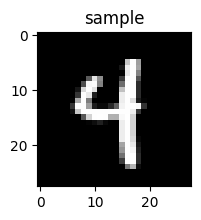

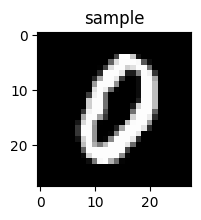

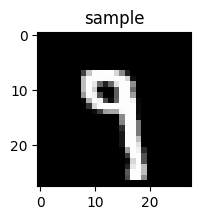

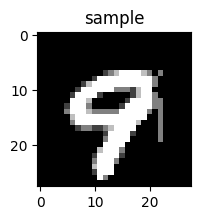

In [89]:
for i in range(0,4):
    random_num = np.random.randint(0,len(x_train))
    img = x_train[random_num]
    imshow("sample",img,size=2)

### 4. Preprocessing our dataset
1. Reshaping the data by adding 4th dimension
2. changing our datatype from uint8 to float32
3. Normalizing our data to values between 0 and 1
4. one hot encoding

In [90]:
x_test.shape

(10000, 28, 28)

In [91]:
img_rows = x_train[0].shape[0]
img_cols = x_train[0].shape[1]

# adding extra dimension
x_train = x_train.reshape(x_train.shape[0],img_rows,img_cols,1)
x_test = x_test.reshape(x_test.shape[0],img_rows,img_cols,1)

# shape for single input image
input_shape = (img_rows, img_cols, 1)

#changing from uint8 to float32
x_train =x_train.astype("float32")
x_test = x_test.astype("float32")

#Normalize the values
x_train = x_train/255.0
x_test = x_test/255.0

print("traing shape {}".format(x_train.shape))

traing shape (60000, 28, 28, 1)


In [92]:
x_test.shape

(10000, 28, 28, 1)

In [93]:
## one hot encoding

from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

num_classes = y_test.shape[1]
print(num_classes)

10


In [94]:
y_train.shape

(60000, 10)

### 5. Building the model

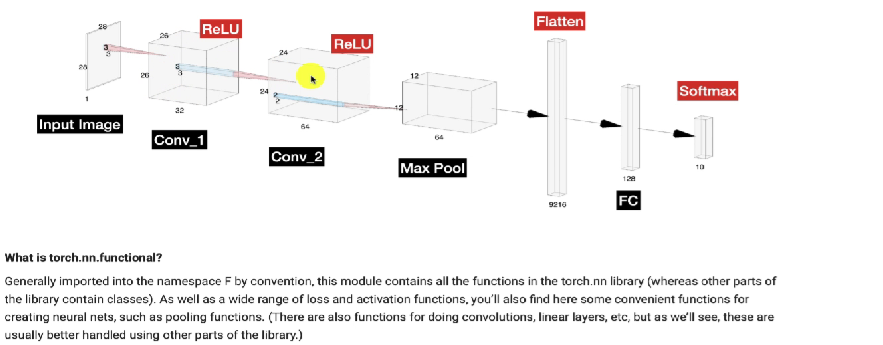

In [95]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv2D, MaxPool2D
from tensorflow.keras import backend as k
from tensorflow.keras.optimizers import SGD


In [96]:
model = Sequential()
model.add(Conv2D(32,(3,3),activation='relu',input_shape=input_shape))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dense(num_classes,activation='softmax'))

In [97]:
model.compile(loss='categorical_crossentropy',optimizer=SGD(0.001),metrics=['accuracy'])

In [98]:
print(model.summary())

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 26, 26, 32)        320       
                                                                 
 conv2d_3 (Conv2D)           (None, 24, 24, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 12, 12, 64)        0         
 g2D)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 9216)              0         
                                                                 
 dense_2 (Dense)             (None, 128)               1179776   
                                                                 
 dense_3 (Dense)             (None, 10)                1290      
                                                      

### 6. Training the model


In [99]:
batch_size = 128
epoch = 2

history = model.fit(x_train,y_train,batch_size,epoch,verbose=1,validation_data=(x_test,y_test))

Epoch 1/2
469/469 [==============================] - 116s 245ms/step - loss: 2.2416 - accuracy: 0.3703 - val_loss: 2.1572 - val_accuracy: 0.6260
Epoch 2/2
469/469 [==============================] - 111s 236ms/step - loss: 1.9152 - accuracy: 0.7032 - val_loss: 1.4528 - val_accuracy: 0.7841


In [100]:
score = model.evaluate(x_test, y_test, verbose=0)
print('test loss', score[0])
print('test accuracy',score[1])

test loss 1.4528439044952393
test accuracy 0.7840999960899353


### 7. plotting loss and accuracy


In [102]:
history.history

{'loss': [2.241584062576294, 1.9152392148971558],
 'accuracy': [0.3702999949455261, 0.703166663646698],
 'val_loss': [2.1572189331054688, 1.4528439044952393],
 'val_accuracy': [0.6259999871253967, 0.7840999960899353]}

## 8. Saving the model

In [103]:
model.save('mnist.h5')

e:\Full Stack data science\pytorch\env\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [104]:
from tensorflow.keras.models import load_model

classifier = load_model('mnist.h5')

### pridict the result

In [110]:
input_im = x_test[0]
print(input_im.shape)

(28, 28, 1)


In [111]:
input_im = input_im.reshape(1,28,28,1)
print(input_im.shape)

(1, 28, 28, 1)


In [112]:
pred = np.argmax(classifier.predict(input_im),axis=1)
print(pred)

1/1 [==============================] - 0s 299ms/step
[7]
